# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-50 Augmented Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-50 model on the Pneumonia dataset with data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.resnet_utils import build_resnet50, DropoutRateScheduler
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

2025-03-23 23:15:07.014754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742771707.031874   24939 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742771707.036852   24939 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-23 23:15:07.053607: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Core Variables

In [2]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'resnet_50_augmented' # Name of the model to be saved
BEST_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_best_model.keras'
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_pneumonia_model.keras'

# Training parameters
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.3
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

# Data Loading & Preprocessing

In [3]:
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_data(
        DATA_PATH, 
        augment=True, 
        batch_size=BATCH_SIZE
    )


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)

Applying data augmentation to training data...


I0000 00:00:1742771716.042219   24939 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 199 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 6.1


# ResNet-50 Model

## Creation & Compilation

In [4]:
# Create and compile model
model = build_resnet50(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │      4,160 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv3 │ (None, 14, 14,    │     16,640 │ stage1_block1_re… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 14, 14,    │     16,640 │ maxpool1[0][0]    │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn3   │ (None, 14, 14,    │      1,024 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 14, 14,    │      1,024 │ stage1_block1_sh… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 256)              │            │ stage1_block1_sh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu3 │ (None, 14, 14,    │          0 │ stage1_block1_ad

 Total params: 23,582,978 (89.96 MB)

 Trainable params: 23,529,858 (89.76 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Callback Definition

In [5]:
# Get callbacks
callbacks = get_callbacks(BEST_MODEL_PATH, monitor=CHOSEN_METRIC, mode='max')
dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=EPOCHS)
callbacks.append(dropout_scheduler)

## Training

In [6]:
# Train model
history = model.fit(
        train_dataset,
        validation_data=(val_images, val_labels),
        epochs=EPOCHS,
        callbacks=callbacks
    )

# Plot training history
plot_training_history(history)

# Save final model
model.save(FINAL_MODEL_PATH)

Epoch 1: dropout rate set to 0.5000
Epoch 1/50


I0000 00:00:1742771762.832215   25009 service.cc:148] XLA service 0x71e130004a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742771762.832234   25009 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1050 Ti with Max-Q Design, Compute Capability 6.1
2025-03-23 23:16:03.478805: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742771766.228186   25009 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-23 23:16:07.819900: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-03-23 23:16:07.880872: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at

UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/rafaela/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>

  File "/home/rafaela/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/rafaela/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start

  File "/home/rafaela/anaconda3/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/home/rafaela/anaconda3/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/home/rafaela/anaconda3/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/home/rafaela/anaconda3/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/home/rafaela/anaconda3/lib/python3.12/s

## Evaluation

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.9022 - accuracy: 0.8522 - loss: 0.7449

2025-03-20 11:32:57.648724: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,14,14]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-03-20 11:32:58.060369: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,7,7]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - AUC: 0.9029 - accuracy: 0.8519 - loss: 0.7387
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step


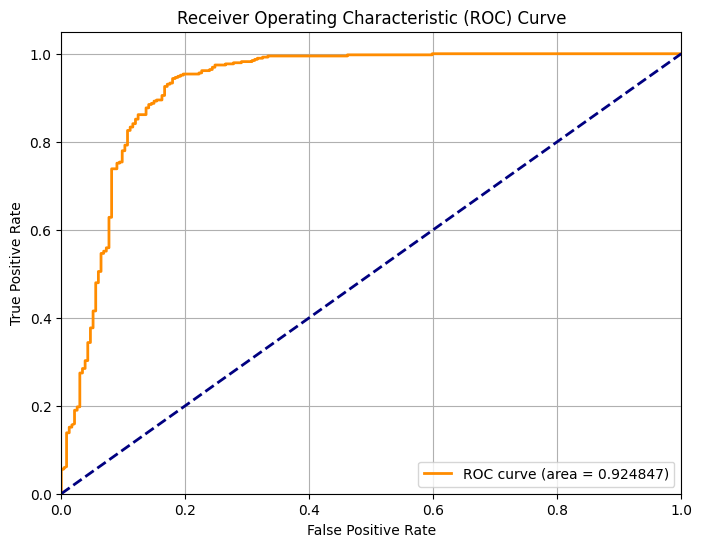

ROC AUC Score: 0.9248


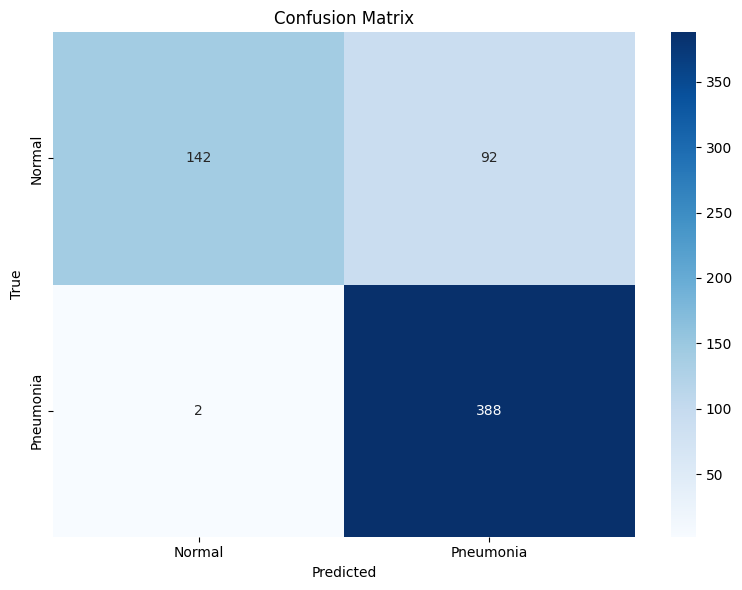

              precision    recall  f1-score   support

      Normal       0.99      0.61      0.75       234
   Pneumonia       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.90      0.80      0.82       624
weighted avg       0.88      0.85      0.84       624



In [7]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

### Comparison

In [8]:
# Load best model from training
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Compare with final model
results_best, results_final = compare_models(best_model, model, test_images, test_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - AUC: 0.9029 - accuracy: 0.8519 - loss: 0.7387
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - AUC: 0.9029 - accuracy: 0.8519 - loss: 0.7387
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Best Model (in Training) vs Selected Model (through callbacks):
Test accuracy: 0.849359 vs 0.849359
Test AUC: 0.924847 vs 0.924847
